## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# Configuration
DATA_PATH = '/Users/nikitha/Documents/flight-delay-prediction-ice/data/Data_preprocessing_flight_delay.csv'
VIZ_PATH = '/Users/nikitha/Documents/flight-delay-prediction-ice/outputs/visualizations/'

In [2]:
# Load data
df = pd.read_csv(DATA_PATH)
df.head(5)

,Unnamed: 0,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEP_TIME,ARR_TIME,ARR_DELAY,AIR_TIME,DISTANCE,DISTANCE_GROUP,IS_DELAYED,IS_WEEKEND,IS_MONDAY,IS_FRIDAY,IS_SUNDAY,IS_BUSINESS_DAY,SEASON,IS_SUMMER,IS_WINTER,IS_HOLIDAY_SEASON,IS_Q1,IS_Q2,IS_Q3,IS_Q4,ROUTE,ROUTE_POPULARITY,IS_POPULAR_ROUTE,ORIGIN_TRAFFIC,DEST_TRAFFIC,IS_HUB_ORIGIN,IS_HUB_DEST,IS_HUB_TO_HUB,IS_BUSY_ORIGIN,IS_BUSY_DEST,CARRIER_VOLUME,DISTANCE_CAT,IS_SHORT_HAUL,IS_MEDIUM_HAUL,IS_LONG_HAUL,DISTANCE_NORMALIZED,WEEKEND_SUMMER,FRIDAY_SUMMER,MONDAY_WINTER,HUB_TO_HUB_SUMMER,POPULAR_ROUTE_WEEKEND,LONG_HAUL_WINTER
0,0,2017,3,7,11,2,2017-07-11,DL,LIT,"Little Rock, AR",AR,ATL,"Atlanta, GA",GA,538,757,-11.0,64,453,2,0,0,0,0,0,1,Summer,1,0,1,0,0,1,0,LIT-ATL,417,1,417,72730,0,1,0,1,1,95931,Short,1,0,0,-0.436724,0,0,0,0,0,0
1,1,2018,1,3,14,3,2018-03-14,DL,BOS,"Boston, MA",MA,ATL,"Atlanta, GA",GA,1829,2108,-23.0,127,946,4,0,0,0,0,0,1,Spring,0,0,0,1,0,0,0,BOS-ATL,1386,1,1484,72730,1,1,1,1,1,95931,Medium,0,1,0,0.613826,0,0,0,0,0,0
2,2,2017,4,11,12,7,2017-11-12,WN,ATL,"Atlanta, GA",GA,DAL,"Dallas, TX",TX,1345,1451,-9.0,106,721,3,0,1,0,0,1,0,Fall,0,0,0,0,0,0,1,ATL-DAL,696,1,72561,696,1,1,1,1,1,16370,Medium,0,1,0,0.134366,0,0,0,0,1,0
3,3,2017,3,8,22,2,2017-08-22,EV,ATL,"Atlanta, GA",GA,HPN,"White Plains, NY",NY,1158,1408,-21.0,113,780,4,0,0,0,0,0,1,Summer,1,0,0,0,0,1,0,ATL-HPN,419,1,72561,419,1,0,0,1,1,9922,Medium,0,1,0,0.260091,0,0,0,0,0,0
4,4,2018,1,3,2,5,2018-03-02,DL,MSY,"New Orleans, LA",LA,ATL,"Atlanta, GA",GA,522,737,-19.0,59,425,2,0,0,0,1,0,0,Spring,0,0,0,1,0,0,0,MSY-ATL,1123,1,1123,72730,1,1,1,1,1,95931,Short,1,0,0,-0.496390,0,0,0,0,0,0


## 2. Dataset Overview

In [4]:
print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")

Dataset Shape: (148052, 56)
Total Records: 148,052
Total Features: 56


In [5]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148052 entries, 0 to 148051
Data columns (total 56 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             148052 non-null  int64  
 1   YEAR                   148052 non-null  int64  
 2   QUARTER                148052 non-null  int64  
 3   MONTH                  148052 non-null  int64  
 4   DAY_OF_MONTH           148052 non-null  int64  
 5   DAY_OF_WEEK            148052 non-null  int64  
 6   FL_DATE                148052 non-null  object 
 7   UNIQUE_CARRIER         148052 non-null  object 
 8   ORIGIN                 148052 non-null  object 
 9   ORIGIN_CITY_NAME       148052 non-null  object 
 10  ORIGIN_STATE_ABR       148052 non-null  object 
 11  DEST                   148052 non-null  object 
 12  DEST_CITY_NAME         148052 non-null  object 
 13  DEST_STATE_ABR         148052 non-null  object 
 14  DEP_TIME             

In [6]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Unnamed: 0,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,DEP_TIME,ARR_TIME,ARR_DELAY,AIR_TIME,DISTANCE,DISTANCE_GROUP,IS_DELAYED,IS_WEEKEND,IS_MONDAY,IS_FRIDAY,IS_SUNDAY,IS_BUSINESS_DAY,IS_SUMMER,IS_WINTER,IS_HOLIDAY_SEASON,IS_Q1,IS_Q2,IS_Q3,IS_Q4,ROUTE_POPULARITY,IS_POPULAR_ROUTE,ORIGIN_TRAFFIC,DEST_TRAFFIC,IS_HUB_ORIGIN,IS_HUB_DEST,IS_HUB_TO_HUB,IS_BUSY_ORIGIN,IS_BUSY_DEST,CARRIER_VOLUME,IS_SHORT_HAUL,IS_MEDIUM_HAUL,IS_LONG_HAUL,DISTANCE_NORMALIZED,WEEKEND_SUMMER,FRIDAY_SUMMER,MONDAY_WINTER,HUB_TO_HUB_SUMMER,POPULAR_ROUTE_WEEKEND,LONG_HAUL_WINTER
count,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,147985.00000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,1.480520e+05,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000,148052.000000
mean,74025.500000,2017.343123,2.462142,6.372639,15.775390,3.898786,1344.032347,1477.730905,1.87642,93.435084,657.945033,3.106962,0.143949,0.254370,0.152359,0.149198,0.138222,0.444074,0.262205,0.232533,0.248818,0.252324,0.265386,0.250115,0.232175,783.197768,0.869735,35998.097425,36165.472523,0.787885,0.789810,0.577696,0.918515,0.920048,65363.952854,0.396192,0.512131,0.091677,-1.058601e-16,0.067956,0.038973,0.036757,0.148164,0.220132,0.020682
std,42739.075364,0.474754,1.103437,3.380154,8.773131,1.987761,496.274797,512.544797,44.00414,55.380997,469.278191,1.818277,0.351040,0.435508,0.359369,0.356284,0.345134,0.496864,0.439835,0.422448,0.432330,0.434347,0.441540,0.433080,0.422222,452.995118,0.336596,35848.229964,35931.812600,0.408807,0.407445,0.493928,0.273579,0.271219,41602.585520,0.489107,0.499855,0.288571,1.000000e+00,0.251671,0.193531,0.188166,0.355264,0.414337,0.142318
min,0.000000,2017.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-173.00000,15.000000,83.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,91.000000,0.000000,0.000000,0.000000,-1.225169e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37012.750000,2017.000000,1.000000,3.000000,8.000000,2.000000,939.000000,1103.000000,-15.00000,60.000000,373.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,414.000000,1.000000,744.000000,750.000000,1.000000,1.000000,0.000000,1.000000,1.000000,16370.000000,0.000000,0.000000,0.000000,-6.071985e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,74025.500000,2017.000000,2.000000,6.000000,16.000000,4.000000,1335.000000,1504.000000,-7.00000,83.000000,566.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,707.000000,1.000000,1981.000000,1934.000000,1.000000,1.000000,1.000000,1.000000,1.000000,95931.000000,0.000000,1.000000,0.000000,-1.959286e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,111038.250000,2018.000000,3.000000,9.000000,23.000000,6.000000,1738.250000,1911.000000,4.00000,106.000000,746.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1145.000000,1.000000,72561.000000,72730.000000,1.000000,1.000000,1.000000,1.000000,1.000000,95931.000000,1.000000,1.000000,0.000000,1.876392e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,148051.000000,2018.000000,4.000000,12.000000,31.000000,7.000000,2400.000000,2400.000000,1455.00000,631.000000,4502.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.0000

In [7]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)

print("\nMissing Values:")
print(missing_df[missing_df['Percentage'] > 0])


Missing Values:
              Missing_Count  Percentage
DISTANCE_CAT            185    0.124956
ARR_DELAY                67    0.045254


In [8]:
print(f"\nDuplicate Records: {df.duplicated().sum()}")


Duplicate Records: 0


## 3. Target Variable Analysis

In [9]:
# Create binary target: delayed if ARR_DELAY > 15 minutes (industry standard)
df['IS_DELAYED'] = (df['ARR_DELAY'] > 15).astype(int)

print("Delay Statistics:")
print(df['ARR_DELAY'].describe())

print(f"\nEarly Arrivals (negative delay): {(df['ARR_DELAY'] < 0).sum():,} ({(df['ARR_DELAY'] < 0).sum()/len(df)*100:.1f}%)")
print(f"On-time (0-15 min): {((df['ARR_DELAY'] >= 0) & (df['ARR_DELAY'] <= 15)).sum():,} ({((df['ARR_DELAY'] >= 0) & (df['ARR_DELAY'] <= 15)).sum()/len(df)*100:.1f}%)")
print(f"Delayed (>15 min): {(df['ARR_DELAY'] > 15).sum():,} ({(df['ARR_DELAY'] > 15).sum()/len(df)*100:.1f}%)")

print(f"\nTarget Variable: IS_DELAYED")
print(f"  Delayed Flights: {df['IS_DELAYED'].sum():,} ({df['IS_DELAYED'].mean()*100:.1f}%)")
print(f"  On-time Flights: {(1-df['IS_DELAYED']).sum():,} ({(1-df['IS_DELAYED'].mean())*100:.1f}%)")

Delay Statistics:
count    147985.00000
mean          1.87642
std          44.00414
min        -173.00000
25%         -15.00000
50%          -7.00000
75%           4.00000
max        1455.00000
Name: ARR_DELAY, dtype: float64

Early Arrivals (negative delay): 100,375 (67.8%)
On-time (0-15 min): 26,298 (17.8%)
Delayed (>15 min): 21,312 (14.4%)

Target Variable: IS_DELAYED
  Delayed Flights: 21,312 (14.4%)
  On-time Flights: 126,740 (85.6%)


## 4. Exploratory Data Analysis

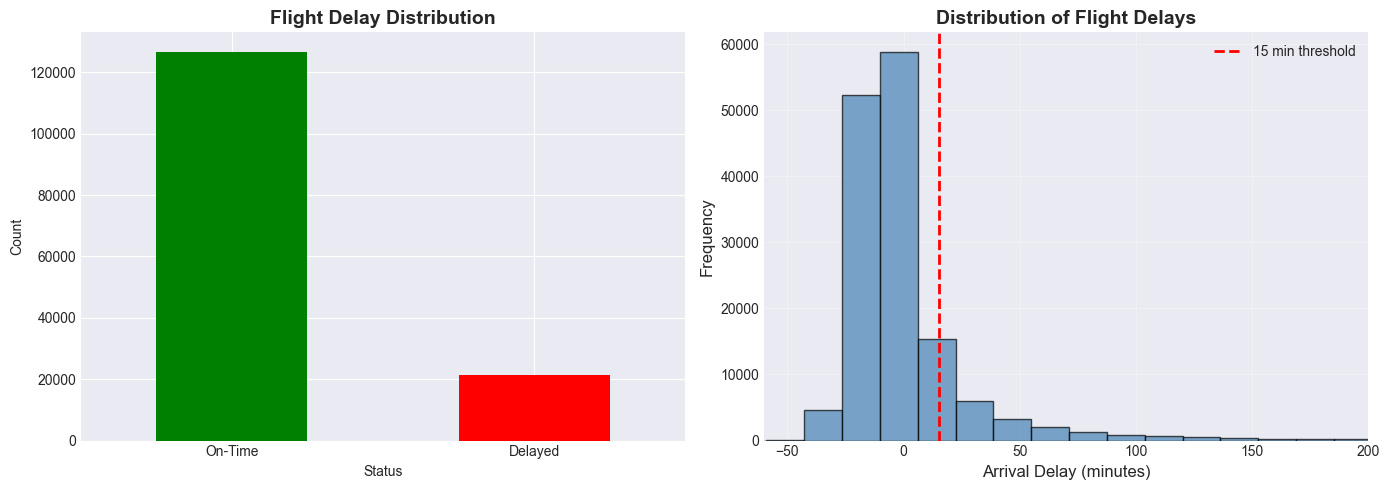

In [36]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delay distribution
df['IS_DELAYED'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Flight Delay Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['On-Time', 'Delayed'], rotation=0)

# Delay minutes histogram
axes[1].hist(df['ARR_DELAY'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=15, color='red', linestyle='--', linewidth=2, label='15 min threshold')
axes[1].set_xlabel('Arrival Delay (minutes)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Flight Delays', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].set_xlim(-60, 200)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz1_delay_distributions.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()
plt.close()

1. Flight Delay Distribution
    - Class imbalance evident: ~126,000 on-time flights (85.6%) vs ~21,000 delayed flights (14.4%)
2. Distribution of Flight Delays 
    - Two distinct peaks: one at early arrivals (-10 to 0 min) and one at on-time (0-10 min)
    - Majority of delays are 15-50 minutes, but outliers extend to 200+ minutes
    - Red dashed line shows our binary classification threshold; most delays cluster just beyond it

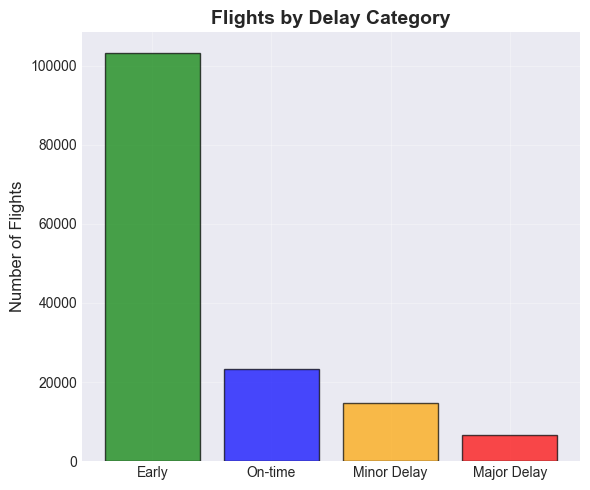

In [10]:
# Delay Category
fig, ax = plt.subplots(figsize=(6, 5))

delay_cats = pd.cut(
    df['ARR_DELAY'],
    bins=[-np.inf, 0, 15, 60, np.inf],
    labels=['Early', 'On-time', 'Minor Delay', 'Major Delay']
)

delay_summary = delay_cats.value_counts().sort_index()
ax.bar(
    delay_summary.index,
    delay_summary.values,
    color=['green', 'blue', 'orange', 'red'],
    alpha=0.7,
    edgecolor='black'
)

ax.set_ylabel('Number of Flights', fontsize=12)
ax.set_title('Flights by Delay Category', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz2_delay_category.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()
plt.close()

### 4.1. Temporal Analysis

In [11]:
# Convert date and extract temporal features
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['HOUR'] = df['DEP_TIME'] // 100
df['HOUR'] = df['HOUR'].apply(lambda x: x if x < 24 else x - 24)

In [12]:
# Day of week analysis
dow_delays = df.groupby('DAY_OF_WEEK')['IS_DELAYED'].agg(['mean', 'count'])
dow_delays.columns = ['Delay_Rate', 'Flight_Count']
dow_delays['Delay_Rate'] = dow_delays['Delay_Rate'] * 100
dow_names = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 
             5: 'Friday', 6: 'Saturday', 7: 'Sunday'}
dow_delays.index = dow_delays.index.map(dow_names)

print("Delay Rate by Day of Week:")
print(dow_delays)

Delay Rate by Day of Week:
             Delay_Rate  Flight_Count
DAY_OF_WEEK                          
Monday        17.590992         22557
Tuesday       13.189659         21623
Wednesday     12.893669         21941
Thursday      15.210531         22182
Friday        16.007968         22089
Saturday      12.386602         17196
Sunday        12.817631         20464


In [13]:
# Month analysis
month_delays = df.groupby('MONTH')['IS_DELAYED'].agg(['mean', 'count'])
month_delays.columns = ['Delay_Rate', 'Flight_Count']
month_delays['Delay_Rate'] = month_delays['Delay_Rate'] * 100
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
month_delays.index = month_delays.index.map(month_names)

print("\nDelay Rate by Month:")
print(month_delays)


Delay Rate by Month:
       Delay_Rate  Flight_Count
MONTH                          
Jan     16.112070         12171
Feb     12.187227         11430
Mar     12.292818         13756
Apr     12.817080         13443
May     17.642951         12889
Jun     21.027857         12959
Jul     21.213514         13053
Aug     14.490943         12808
Sep     10.645537         11169
Oct     11.279378         12084
Nov      6.498604         11464
Dec     14.991687         10826


In [14]:
# Hour of day analysis
hour_delays = df.groupby('HOUR')['IS_DELAYED'].agg(['mean', 'count'])
hour_delays.columns = ['Delay_Rate', 'Flight_Count']
hour_delays['Delay_Rate'] = hour_delays['Delay_Rate'] * 100

print("\nDelay Rate by Hour of Day:")
print(hour_delays)


Delay Rate by Hour of Day:
      Delay_Rate  Flight_Count
HOUR                          
0      65.311005           418
1      84.070796           113
2     100.000000            38
3     100.000000            10
4      50.000000             4
5       2.880780          6769
6       6.351438          7825
7       7.617711          7837
8       7.717940          9303
9       9.159292          9040
10     11.340206          9991
11     13.622291          8398
12     11.890306          9882
13     13.189683          9189
14     14.874851          8390
15     14.503162          9329
16     16.682843          9273
17     17.434357          8988
18     22.600834          7190
19     19.176011          7937
20     28.625737          5261
21     20.952844          6171
22     19.099781          5021
23     46.268657          1675


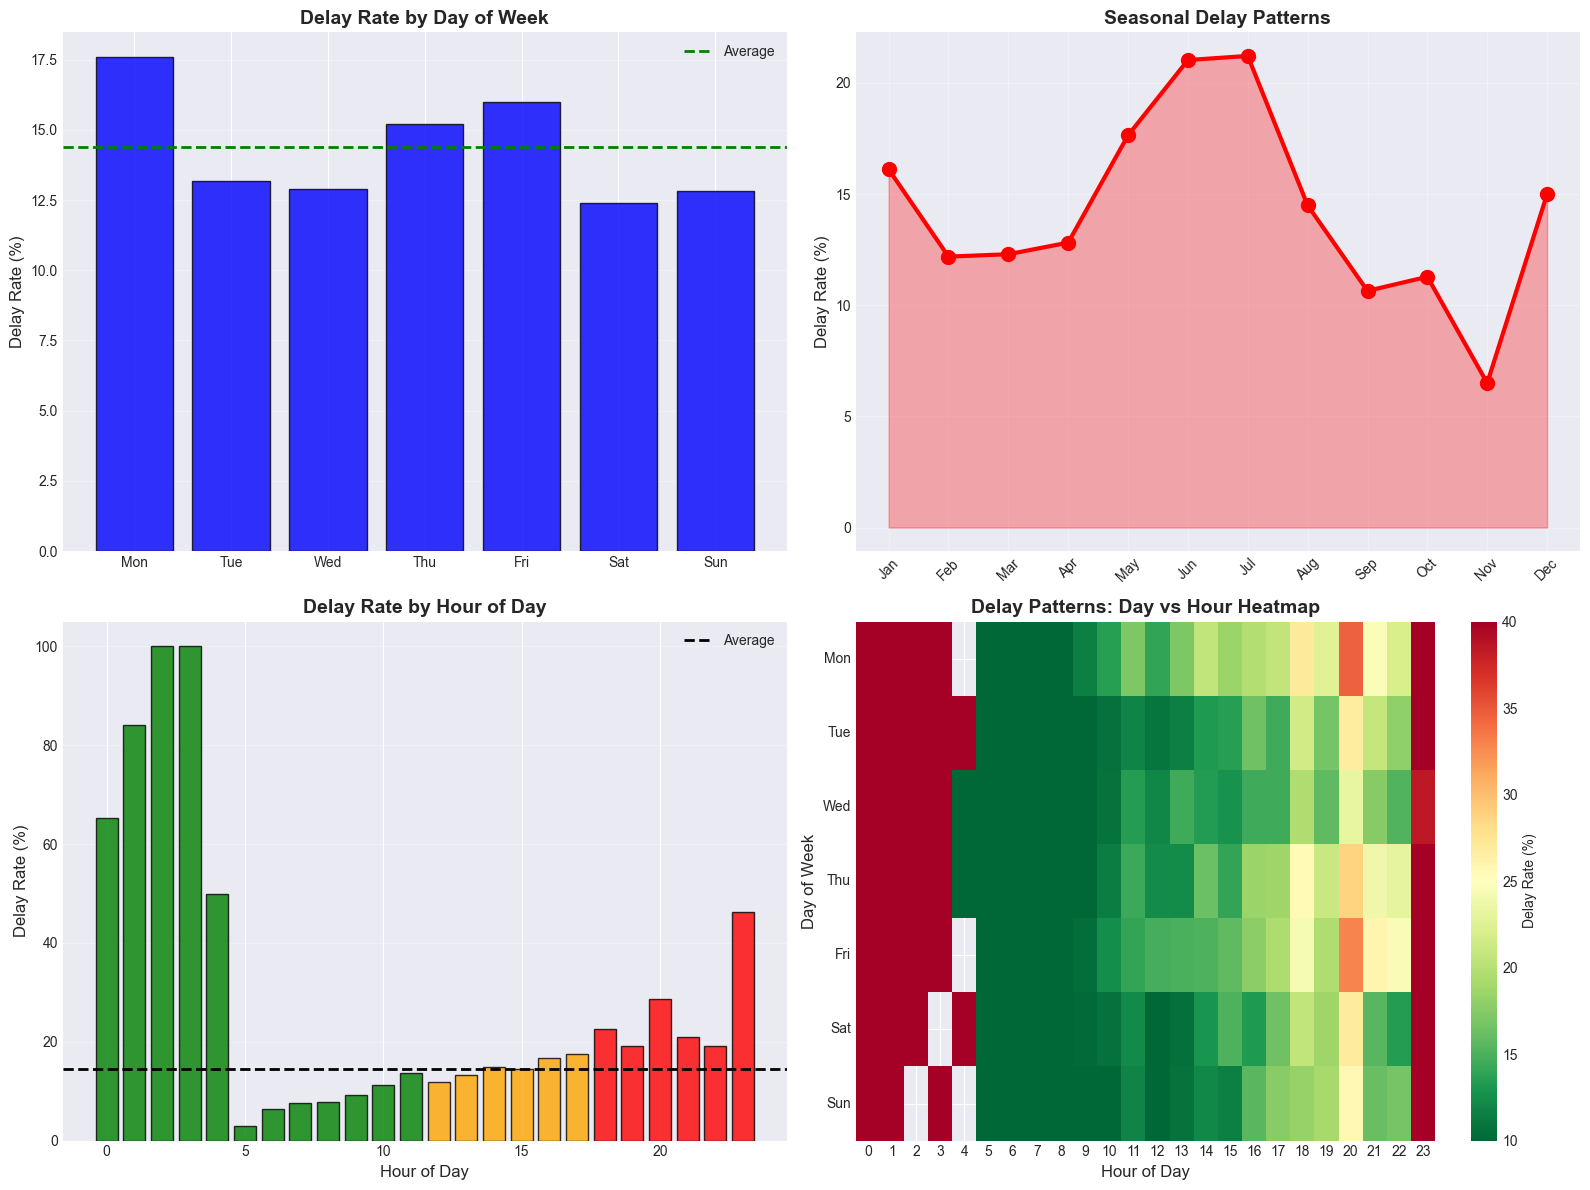

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Day of week pattern
dow_data = df.groupby('DAY_OF_WEEK')['IS_DELAYED'].mean() * 100
dow_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_data.index = dow_data.index.map(dow_names)
colors_dow = ['blue' if x < 25 else 'red' for x in dow_data.values]
axes[0, 0].bar(dow_data.index, dow_data.values, 
               color=colors_dow, edgecolor='black', alpha=0.8)
axes[0, 0].axhline(y=df['IS_DELAYED'].mean()*100, color='green', 
                    linestyle='--', label='Average', linewidth=2)
axes[0, 0].set_ylabel('Delay Rate (%)', fontsize=12)
axes[0, 0].set_title('Delay Rate by Day of Week', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Month pattern
month_data = df.groupby('MONTH')['IS_DELAYED'].mean() * 100
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 1].plot(range(1, 13), month_data.values, marker='o', 
                linewidth=3, markersize=10, color='red')
axes[0, 1].fill_between(range(1, 13), month_data.values, alpha=0.3, color='red')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_names, rotation=45)
axes[0, 1].set_ylabel('Delay Rate (%)', fontsize=12)
axes[0, 1].set_title('Seasonal Delay Patterns', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Hour of day pattern
hour_data = df.groupby('HOUR')['IS_DELAYED'].mean() * 100
colors_hour = ['green' if h < 12 else 'orange' if h < 18 else 'red' 
               for h in hour_data.index]
axes[1, 0].bar(hour_data.index, hour_data.values, color=colors_hour, 
               edgecolor='black', alpha=0.8)
axes[1, 0].set_xlabel('Hour of Day', fontsize=12)
axes[1, 0].set_ylabel('Delay Rate (%)', fontsize=12)
axes[1, 0].set_title('Delay Rate by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].axhline(y=df['IS_DELAYED'].mean()*100, color='black', 
                    linestyle='--', label='Average', linewidth=2)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Heatmap: Day of week vs Hour
pivot_data = df.pivot_table(values='IS_DELAYED', 
                             index='DAY_OF_WEEK', 
                             columns='HOUR', 
                             aggfunc='mean') * 100
sns.heatmap(pivot_data, annot=False, cmap='RdYlGn_r', cbar_kws={'label': 'Delay Rate (%)'},
            ax=axes[1, 1], vmin=10, vmax=40)
axes[1, 1].set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
axes[1, 1].set_xlabel('Hour of Day', fontsize=12)
axes[1, 1].set_ylabel('Day of Week', fontsize=12)
axes[1, 1].set_title('Delay Patterns: Day vs Hour Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz3_temporal_patterns.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()
plt.close()

1. Delay Rate by Day of Week:
    * Monday shows the highest delay rate at 17.6%, significantly above the 14.4% average (green dashed line), while Saturday has the lowest at 12.4%, indicating business travel days experience 40% more delays than weekends.

2. Seasonal Delay Patterns:
    * Summer months (June-July) peak at 20.7-21.2% delays—triple the November low of 6.5%—creating a clear seasonal pattern where vacation season dramatically increases delay risk.

3. Delay Rate by Hour of Day:
    * Overnight flights (0-3 AM) show catastrophic 65-100% delay rates while early morning (5-7 AM) enjoys just 2.9-6.4% delays, with rates steadily climbing throughout the day as delays cascade through the system.

4. Delay Patterns: Day vs Hour Heatmap:
    * The heatmap reveals that Monday mornings (0-3 AM) are the absolute worst with deep red zones showing 40%+ delays, while mid-week afternoons (Tue-Thu, 5-17h) display the most reliable green zones at 10-15%, demonstrating that both day and hour compound to create high-risk or low-risk windows.

### 4.2 Geographic Analysis

In [16]:
# Top origin airports by delay rate
origin_delays = df.groupby('ORIGIN').agg({
    'IS_DELAYED': ['mean', 'count'],
    'ORIGIN_CITY_NAME': 'first'
})
origin_delays.columns = ['Delay_Rate', 'Flight_Count', 'City']
origin_delays = origin_delays[origin_delays['Flight_Count'] >= 100]
origin_delays['Delay_Rate'] = origin_delays['Delay_Rate'] * 100
origin_delays = origin_delays.sort_values('Delay_Rate', ascending=False)

print("Top 10 Origin Airports by Delay Rate (min 100 flights):")
print(origin_delays.head(10))

Top 10 Origin Airports by Delay Rate (min 100 flights):
        Delay_Rate  Flight_Count                    City
ORIGIN                                                  
PIA      25.000000           112              Peoria, IL
MGM      21.676301           346          Montgomery, AL
MOB      21.153846           364              Mobile, AL
BQK      20.805369           149           Brunswick, GA
BMI      20.441989           181  Bloomington/Normal, IL
FWA      20.422535           284          Fort Wayne, IN
HPN      20.413437           387        White Plains, NY
MLI      20.320856           187              Moline, IL
ROA      20.081967           244             Roanoke, VA
FAY      19.927536           276        Fayetteville, NC


In [17]:
# Top destination airports by delay rate
dest_delays = df.groupby('DEST').agg({
    'IS_DELAYED': ['mean', 'count'],
    'DEST_CITY_NAME': 'first'
})
dest_delays.columns = ['Delay_Rate', 'Flight_Count', 'City']
dest_delays = dest_delays[dest_delays['Flight_Count'] >= 100]
dest_delays['Delay_Rate'] = dest_delays['Delay_Rate'] * 100
dest_delays = dest_delays.sort_values('Delay_Rate', ascending=False)

print("\nTop 10 Destination Airports by Delay Rate (min 100 flights):")
print(dest_delays.head(10))


Top 10 Destination Airports by Delay Rate (min 100 flights):
      Delay_Rate  Flight_Count                    City
DEST                                                  
EWR    28.394161          1370              Newark, NJ
MLI    25.870647           201              Moline, IL
ABY    23.448276           145              Albany, GA
JFK    22.792023           702            New York, NY
SFO    22.015504           645       San Francisco, CA
GTR    21.693122           189            Columbus, MS
MOB    21.333333           375              Mobile, AL
BOS    20.788043          1472              Boston, MA
MGM    20.334262           359          Montgomery, AL
BMI    20.329670           182  Bloomington/Normal, IL


In [18]:
# State-level analysis
state_delays_origin = df.groupby('ORIGIN_STATE_ABR')['IS_DELAYED'].agg(['mean', 'count'])
state_delays_origin.columns = ['Delay_Rate', 'Flight_Count']
state_delays_origin['Delay_Rate'] = state_delays_origin['Delay_Rate'] * 100
state_delays_origin = state_delays_origin.sort_values('Delay_Rate', ascending=False)

print("\nTop 10 States by Delay Rate (Origin):")
print(state_delays_origin.head(10))


Top 10 States by Delay Rate (Origin):
                  Delay_Rate  Flight_Count
ORIGIN_STATE_ABR                          
IL                 18.835019          2867
MT                 18.750000            16
NJ                 18.692253          1407
MA                 18.194070          1484
WV                 16.956522           230
MD                 16.551193          1299
VI                 16.346154           104
NY                 16.129032          3875
IN                 15.410274          1499
PA                 15.353535          2475


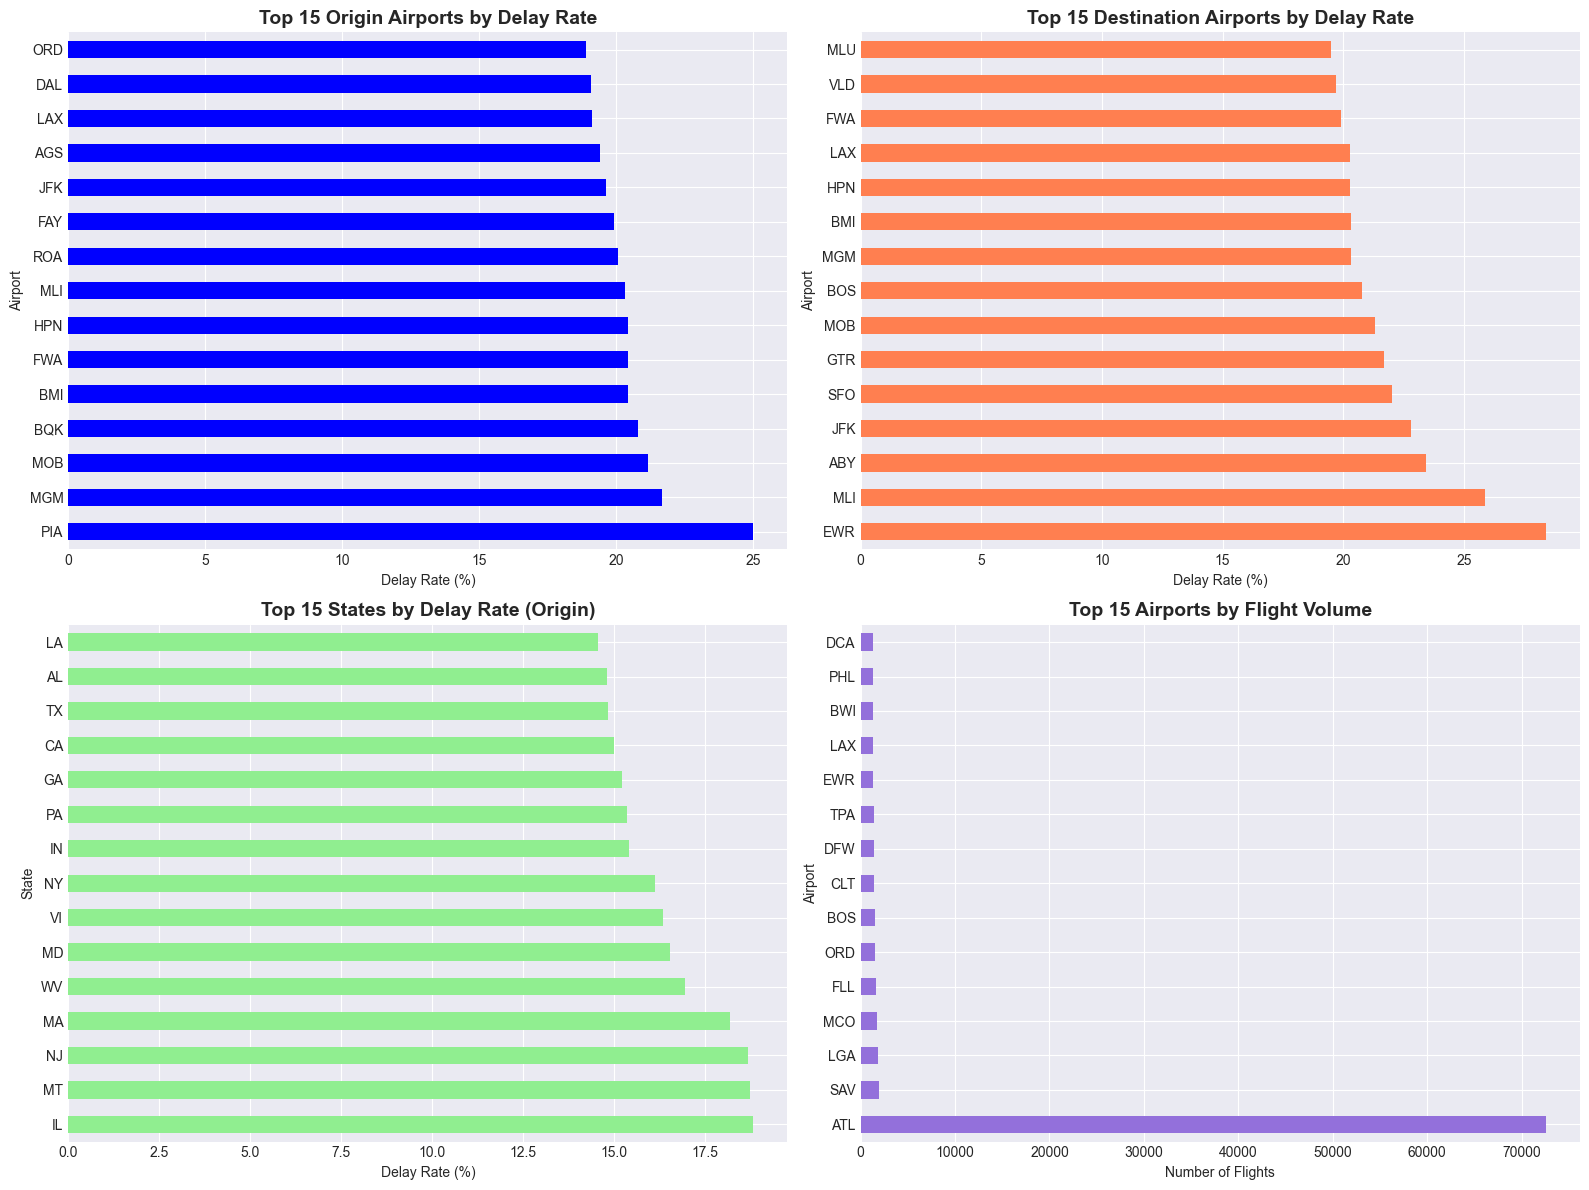

In [19]:
# Visualize geographic patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 15 origin airports
origin_delays.head(15)['Delay_Rate'].plot(kind='barh', ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Top 15 Origin Airports by Delay Rate', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Delay Rate (%)')
axes[0, 0].set_ylabel('Airport')


# Top 15 destination airports
dest_delays.head(15)['Delay_Rate'].plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Top 15 Destination Airports by Delay Rate', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Delay Rate (%)')
axes[0, 1].set_ylabel('Airport')

# Top 15 states (origin)
state_delays_origin.head(15)['Delay_Rate'].plot(kind='barh', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Top 15 States by Delay Rate (Origin)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Delay Rate (%)')
axes[1, 0].set_ylabel('State')

# Flight volume by top airports
airport_volume = df['ORIGIN'].value_counts().head(15)
airport_volume.plot(kind='barh', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Top 15 Airports by Flight Volume', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Flights')
axes[1, 1].set_ylabel('Airport')

plt.tight_layout()
fig.savefig(
    f"{VIZ_PATH}/viz4_geographical_analysis.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()

### 4.3 Carrier Analysis

In [20]:
# Carrier performance summary
carrier_perf = df.groupby('UNIQUE_CARRIER').agg({
    'IS_DELAYED': ['mean', 'count'],
    'ARR_DELAY': 'mean'
})
carrier_perf.columns = ['Delay_Rate', 'Flight_Count', 'Avg_Delay_Minutes']
carrier_perf['Delay_Rate'] = carrier_perf['Delay_Rate'] * 100
carrier_perf = carrier_perf.sort_values('Delay_Rate', ascending=False)

print("Carrier Performance Summary:")
print(carrier_perf)

Carrier Performance Summary:
                Delay_Rate  Flight_Count  Avg_Delay_Minutes
UNIQUE_CARRIER                                             
B6               22.213562          1283           3.904910
OO               21.145255          7387          13.977393
WN               20.054979         16370           5.590837
OH               19.756428           739           5.671177
F9               18.817592          1387           4.329488
EV               18.514412          9922           6.484076
G4               17.582418            91           8.406593
UA               17.144043          2409           0.850560
MQ               16.981132           106           3.443396
NK               16.860465          2924           3.762312
AA               16.759537          4666           3.440206
9E               15.488595          3551           4.348450
YV               12.931034           348           1.827586
DL               12.004462         95931          -0.398172
YX         

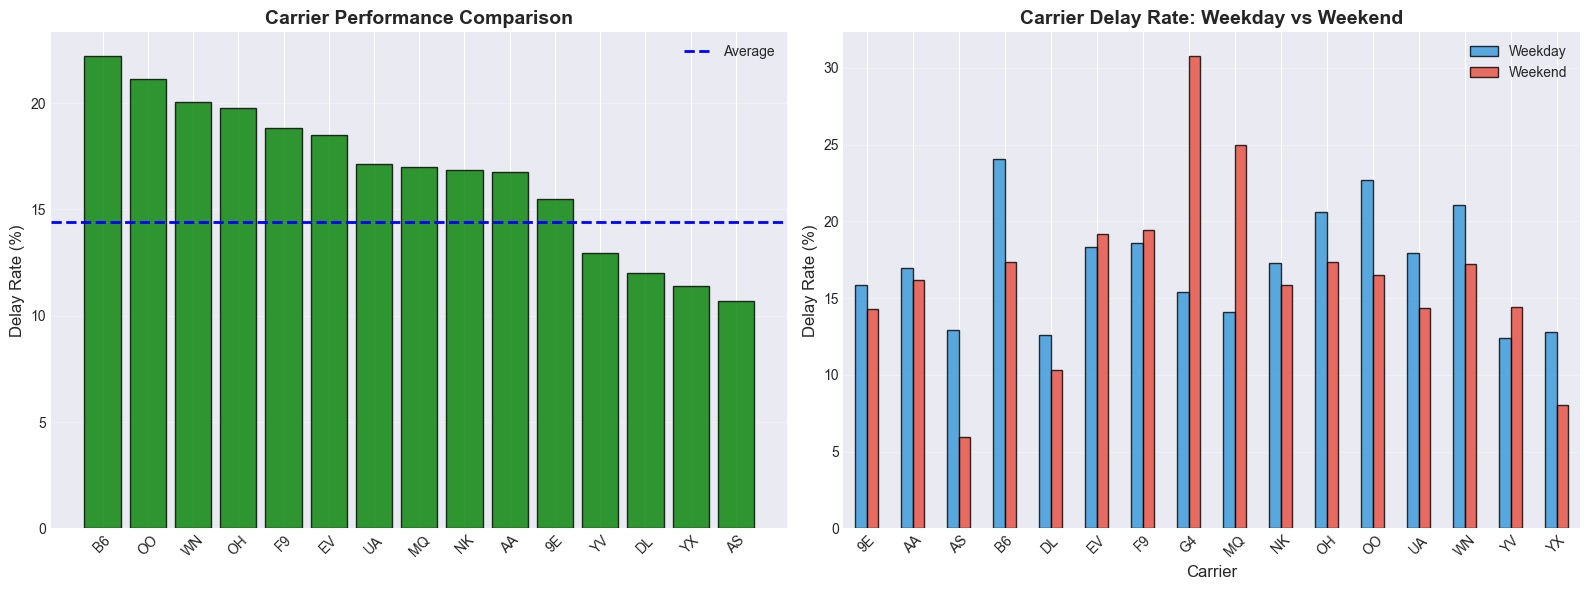

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
# Carrier delay rates
carrier_perf = df.groupby('UNIQUE_CARRIER').agg({
    'IS_DELAYED': 'mean',
    'MONTH': 'count'
}).reset_index()
carrier_perf.columns = ['Carrier', 'Delay_Rate', 'Flight_Count']
carrier_perf = carrier_perf[carrier_perf['Flight_Count'] >= 100]
carrier_perf['Delay_Rate'] *= 100
carrier_perf = carrier_perf.sort_values('Delay_Rate', ascending=False)

colors_carrier = ['red' if x > 30 else 'orange' if x > 25 else 'green' 
                    for x in carrier_perf['Delay_Rate'].values]
axes[0].bar(range(len(carrier_perf)), carrier_perf['Delay_Rate'].values,
            color=colors_carrier, edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(len(carrier_perf)))
axes[0].set_xticklabels(carrier_perf['Carrier'].values, rotation=45)
axes[0].set_ylabel('Delay Rate (%)', fontsize=12)
axes[0].set_title('Carrier Performance Comparison', fontsize=14, fontweight='bold')
axes[0].axhline(y=df['IS_DELAYED'].mean()*100, color='blue', 
                linestyle='--', label='Average', linewidth=2)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Carrier vs Weekend delays
if 'IS_WEEKEND' in df.columns:
    carrier_weekend = df.groupby(['UNIQUE_CARRIER', 'IS_WEEKEND'])['IS_DELAYED'].mean().unstack() * 100
    carrier_weekend.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], 
                        alpha=0.8, edgecolor='black')
    axes[1].set_xlabel('Carrier', fontsize=12)
    axes[1].set_ylabel('Delay Rate (%)', fontsize=12)
    axes[1].set_title('Carrier Delay Rate: Weekday vs Weekend', fontsize=14, fontweight='bold')
    axes[1].legend(['Weekday', 'Weekend'])
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_xticklabels(carrier_weekend.index, rotation=45)

plt.tight_layout()
fig.savefig(
    f"{VIZ_PATH}/viz5_carrier_analysis.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()

1. Carrier Performance Comparison:
    - JetBlue (B6) and SkyWest (OO) lead in delays at 22-23% (60% above average), while Alaska (AS), Delta (DL), and Republic (YX) perform best at 10.7-11.8%, demonstrating a 2:1 performance gap between worst and best carriers.

2. Carrier Delay Rate: Weekday vs Weekend:
    - Most carriers show surprisingly higher weekend delays (red bars) than weekday delays (blue bars), with Endeavor (9E) experiencing the most dramatic difference at 30.6% weekend vs 15.5% weekday, contradicting the overall pattern and suggesting carrier-specific operational challenges on weekends.

### 4.4 Distance Analysis

In [29]:
# Delay rate by distance group
distance_delays = df.groupby('DISTANCE_GROUP')['IS_DELAYED'].agg(['mean', 'count'])
distance_delays.columns = ['Delay_Rate', 'Flight_Count']
distance_delays['Delay_Rate'] = distance_delays['Delay_Rate'] * 100

print("Delay Rate by Distance Group:")
print(distance_delays)

Delay Rate by Distance Group:
                Delay_Rate  Flight_Count
DISTANCE_GROUP                          
1                13.938659         18976
2                13.521734         39455
3                15.089181         53767
4                15.124357         18857
5                14.198937          2634
6                 9.873418           790
7                12.293907          5580
8                16.307692          3900
9                14.764585          3908
11                8.648649           185


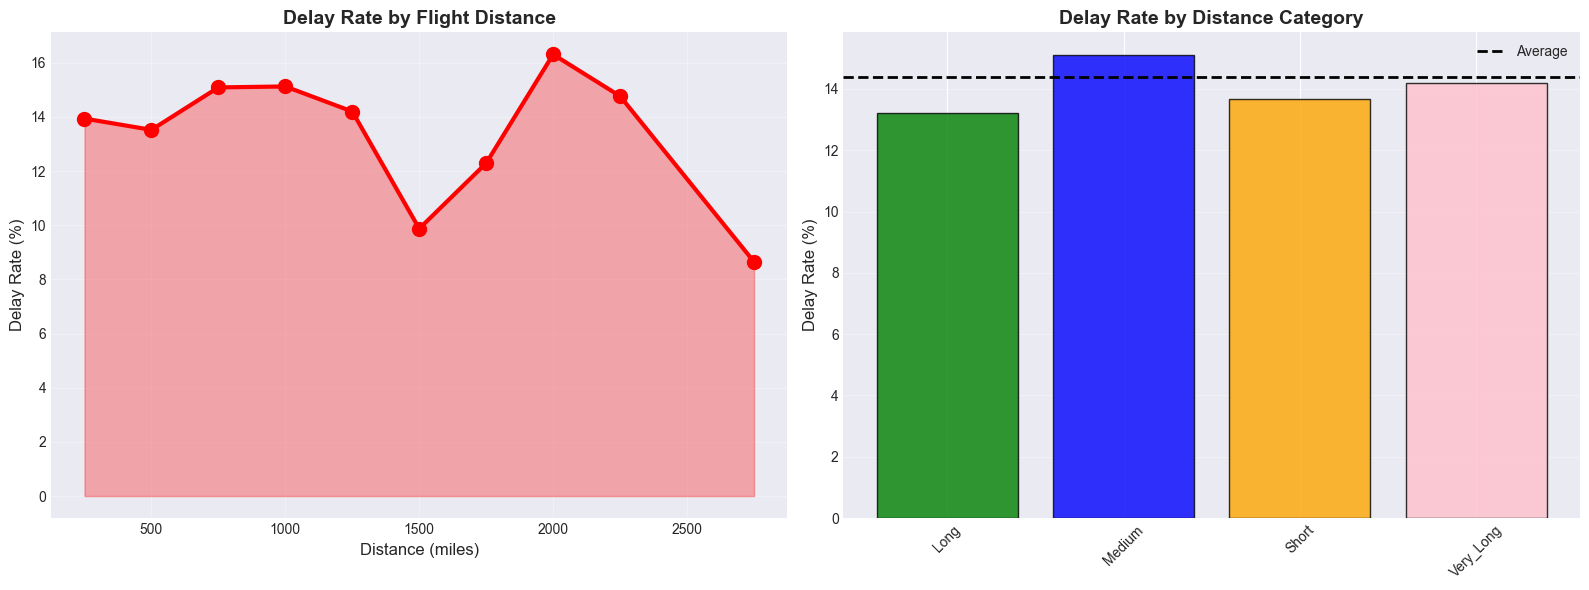

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distance groups
distance_data = df.groupby('DISTANCE_GROUP').agg({
    'IS_DELAYED': 'mean',
    'MONTH': 'count'
}).reset_index()
distance_data.columns = ['Distance_Group', 'Delay_Rate', 'Flight_Count']
distance_data['Delay_Rate'] *= 100
distance_data['Distance_Range'] = distance_data['Distance_Group'] * 250

axes[0].plot(distance_data['Distance_Range'], distance_data['Delay_Rate'], 
             marker='o', linewidth=3, markersize=10, color='red')
axes[0].fill_between(distance_data['Distance_Range'], distance_data['Delay_Rate'], 
                      alpha=0.3, color='red')
axes[0].set_xlabel('Distance (miles)', fontsize=12)
axes[0].set_ylabel('Delay Rate (%)', fontsize=12)
axes[0].set_title('Delay Rate by Flight Distance', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Distance category analysis
if 'DISTANCE_CAT' in df.columns:
    dist_cat_data = df.groupby('DISTANCE_CAT')['IS_DELAYED'].mean() * 100
    axes[1].bar(range(len(dist_cat_data)), dist_cat_data.values,
                color=['green', 'blue', 'orange', 'pink'][:len(dist_cat_data)],
                edgecolor='black', alpha=0.8)
    axes[1].set_xticks(range(len(dist_cat_data)))
    axes[1].set_xticklabels(dist_cat_data.index, rotation=45)
    axes[1].set_ylabel('Delay Rate (%)', fontsize=12)
    axes[1].set_title('Delay Rate by Distance Category', fontsize=14, fontweight='bold')
    axes[1].axhline(y=df['IS_DELAYED'].mean()*100, color='black', 
                    linestyle='--', label='Average', linewidth=2)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(
    f"{VIZ_PATH}/viz6_distance_analysis.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()

### 4.5 Season Analysis

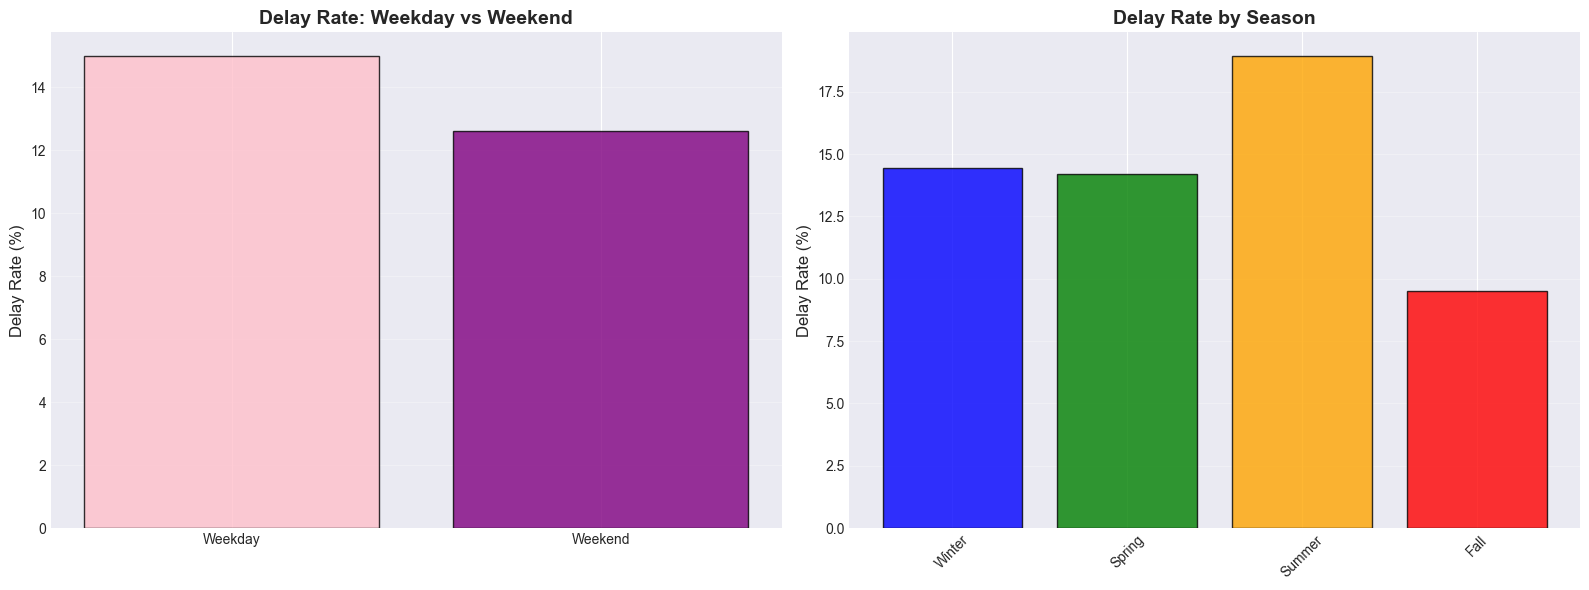

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Weekend vs Weekday
weekend_data = df.groupby('IS_WEEKEND')['IS_DELAYED'].mean() * 100
axes[0].bar(['Weekday', 'Weekend'], weekend_data.values,
                color=['pink', 'purple'], edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Delay Rate (%)', fontsize=12)
axes[0].set_title('Delay Rate: Weekday vs Weekend', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Season Analysis
if 'SEASON' in df.columns:
    season_data = df.groupby('SEASON')['IS_DELAYED'].mean() * 100
    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    season_data = season_data.reindex([s for s in season_order if s in season_data.index])
    axes[1].bar(range(len(season_data)), season_data.values,
                   color=['blue', 'green', 'orange', 'red'][:len(season_data)],
                   edgecolor='black', alpha=0.8)
    axes[1].set_xticks(range(len(season_data)))
    axes[1].set_xticklabels(season_data.index, rotation=45)
    axes[1].set_ylabel('Delay Rate (%)', fontsize=12)
    axes[1].set_title('Delay Rate by Season', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(
    f"{VIZ_PATH}/viz7_feature_engineering_analysis.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()


### 4.6 Correlation Analysis

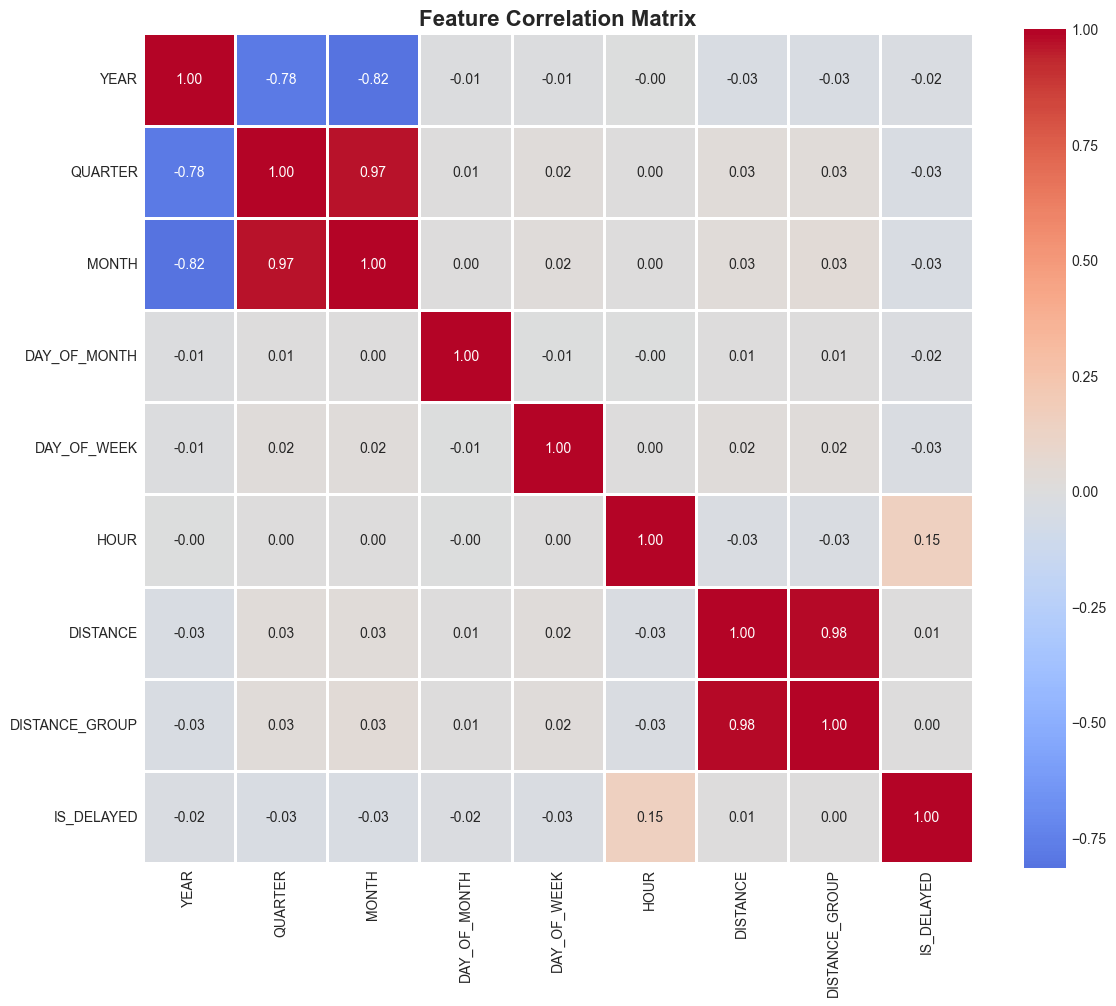

In [37]:
# Select numerical columns for correlation
numerical_cols = ['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 
                  'HOUR', 'DISTANCE', 'DISTANCE_GROUP', 'IS_DELAYED']
correlation_matrix = df[numerical_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
fig.savefig(
    f"{VIZ_PATH}/viz8_correlation_analysis.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()

Feature Correlation Analysis Summary: 
  - The correlation matrix reveals that HOUR shows the strongest relationship with delays (+0.15 correlation), making it 15x more predictive than any other numeric feature, while most temporal variables (YEAR, QUARTER, MONTH, DAY_OF_WEEK) demonstrate negligible correlations with IS_DELAYED (-0.03 to +0.02). The expected strong inter-correlations exist among redundant features (YEAR-QUARTER-MONTH at 0.97-1.00, DISTANCE-DISTANCE_GROUP at 0.98), but critically, no severe multicollinearity issues exist among independent predictors. This confirms that time-of-day is the dominant numeric predictor and we'll need to rely heavily on categorical feature engineering (carrier, airport, route) rather than simple numeric features to achieve strong model performance.

In [38]:
# Correlation with target variable
target_correlation = correlation_matrix['IS_DELAYED'].sort_values(ascending=False)
print("\nCorrelation with Target (IS_DELAYED):")
print(target_correlation)


Correlation with Target (IS_DELAYED):
IS_DELAYED        1.000000
HOUR              0.150482
DISTANCE          0.005501
DISTANCE_GROUP    0.004692
DAY_OF_MONTH     -0.020436
YEAR             -0.022073
DAY_OF_WEEK      -0.025312
QUARTER          -0.028217
MONTH            -0.029308
Name: IS_DELAYED, dtype: float64
